# Notebook 04 — Main experiment + hyperparameter sweeps

APBIO project, 2025/26.

This is the notebook that produces the numbers and plots for the final
report. Four blocks:

1. **Main experiment:** 5 seeds × {baseline, hybrid}. Reports mean ± std
   learning curves, sample efficiency, convergence score, training
   stability, relative improvement, and a significance test.
2. **Sweep 1 — Hopfield beta** (bio-inspired hyperparameter).
3. **Sweep 2 — Hopfield capacity** (structural hyperparameter).
4. **Sweep 3 — Learning rate** (RL hyperparameter).

Every run writes its CSV to Drive immediately, so if the Colab session
disconnects mid-way I can restart and skip anything that already finished.
Total wall-clock is roughly 90 minutes on a CPU runtime.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, pathlib

PROJECT_ROOT = pathlib.Path('/content/drive/MyDrive/apbio_project')
(PROJECT_ROOT / 'logs').mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / 'logs' / 'sweeps').mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / 'figures').mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_ROOT)
print('cwd:', os.getcwd())

cwd: /content/drive/MyDrive/apbio_project


In [3]:
%pip install -q 'gymnasium>=0.29' 'stable-baselines3>=2.3'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 5.3 MB/s eta 0:00:00


In [4]:
import csv, random, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

from stable_baselines3 import DQN
from stable_baselines3.common.buffers import ReplayBuffer
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Hopfield memory + replay buffer (same as notebook 03)

In [6]:
class HopfieldMemory(nn.Module):
    def __init__(self, capacity, dim, beta=1.0):
        super().__init__()
        self.capacity = capacity
        self.dim = dim
        self.beta = beta
        self.register_buffer('patterns', torch.zeros(capacity, dim))
        self.register_buffer('size', torch.tensor(0, dtype=torch.long))

    def store(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        n = x.shape[0]
        s = int(self.size.item())
        idx = (torch.arange(n) + s) % self.capacity
        self.patterns[idx] = x.to(self.patterns.dtype)
        self.size.fill_(min(s + n, self.capacity))

    def retrieve_weights(self, query):
        if query.dim() == 1:
            query = query.unsqueeze(0)
        s = int(self.size.item())
        if s == 0:
            raise RuntimeError('empty memory')
        X = self.patterns[:s]
        scores = self.beta * query @ X.T
        return torch.softmax(scores, dim=-1), s


class HopfieldReplayBuffer(ReplayBuffer):
    def __init__(self, buffer_size, observation_space, action_space,
                 device='auto', n_envs=1,
                 hopfield_beta=5.0, hopfield_capacity=None,
                 **kwargs):
        super().__init__(buffer_size, observation_space, action_space,
                         device=device, n_envs=n_envs, **kwargs)
        obs_dim = int(np.prod(observation_space.shape))
        cap = hopfield_capacity if hopfield_capacity is not None else buffer_size
        self.hopfield = HopfieldMemory(capacity=cap, dim=obs_dim, beta=hopfield_beta)
        self._last_obs = None

    def add(self, obs, next_obs, action, reward, done, infos):
        super().add(obs, next_obs, action, reward, done, infos)
        obs_t = torch.as_tensor(obs, dtype=torch.float32)
        if obs_t.dim() == 1:
            obs_t = obs_t.unsqueeze(0)
        self.hopfield.store(obs_t)
        self._last_obs = obs_t[-1].clone()

    def sample(self, batch_size, env=None):
        if self.size() == 0 or self._last_obs is None:
            return super().sample(batch_size, env=env)
        weights, n_stored = self.hopfield.retrieve_weights(self._last_obs)
        weights = weights.squeeze(0).detach().cpu().numpy()
        upper = min(n_stored, self.size())
        weights = weights[:upper]
        weights = weights / weights.sum()
        batch_inds = np.random.choice(upper, size=batch_size, replace=True, p=weights)
        return self._get_samples(batch_inds, env=env)

## 3. Logger + one-run trainer

A single `run()` function takes a config dict and produces a CSV. I use a
dict so the same function handles the baseline, the hybrid, and the sweeps.

In [7]:
class EpisodeLogger(BaseCallback):
    def __init__(self, csv_path):
        super().__init__()
        self.csv_path = Path(csv_path)
        self.csv_path.parent.mkdir(parents=True, exist_ok=True)
        self._ep = 0
        with self.csv_path.open('w', newline='') as f:
            csv.writer(f).writerow(['episode', 'timestep', 'return', 'length'])

    def _on_step(self):
        finished = []
        for info in self.locals.get('infos', []):
            if 'episode' in info:
                self._ep += 1
                finished.append([self._ep, self.num_timesteps,
                                 float(info['episode']['r']), int(info['episode']['l'])])
        if finished:
            with self.csv_path.open('a', newline='') as f:
                csv.writer(f).writerows(finished)
        return True

In [21]:
TOTAL_TIMESTEPS = 50_000

DEFAULT_CFG = dict(
    learning_rate=2.3e-3,
    buffer_size=100_000,
    learning_starts=1_000,
    batch_size=64,
    tau=1.0,
    gamma=0.99,
    train_freq=256,
    gradient_steps=128,
    target_update_interval=10,
    exploration_fraction=0.16,
    exploration_final_eps=0.04,
    net_arch=[256, 256],
)

def run(csv_path, seed, mode='baseline', total_timesteps=TOTAL_TIMESTEPS,
        hopfield_beta=5.0, hopfield_capacity=None, overrides=None):
    """Train one DQN run and write its per-episode CSV.

    If csv_path already exists and is non-empty, return immediately — this
    lets the notebook resume after a disconnect.
    """
    csv_path = Path(csv_path)
    if csv_path.exists() and csv_path.stat().st_size > 60:
    # Check that the cached run actually finished — not a truncated one.
      try:
        tail = pd.read_csv(csv_path)
        if len(tail) > 0 and tail['timestep'].max() >= 0.9 * total_timesteps:
            return csv_path, 0.0, True  # cached and complete
      except Exception:
        pass
    # Otherwise fall through and retrain.

    cfg = dict(DEFAULT_CFG)
    if overrides:
        cfg.update(overrides)

    set_seed(seed)
    env = Monitor(gym.make('CartPole-v1'))

    kwargs = dict(
        policy='MlpPolicy',
        env=env,
        learning_rate=cfg['learning_rate'],
        buffer_size=cfg['buffer_size'],
        learning_starts=cfg['learning_starts'],
        batch_size=cfg['batch_size'],
        tau=cfg['tau'],
        gamma=cfg['gamma'],
        train_freq=cfg['train_freq'],
        gradient_steps=cfg['gradient_steps'],
        target_update_interval=cfg['target_update_interval'],
        exploration_fraction=cfg['exploration_fraction'],
        exploration_final_eps=cfg['exploration_final_eps'],
        policy_kwargs=dict(net_arch=cfg['net_arch']),
        seed=seed,
        verbose=0,
    )
    if mode == 'hybrid':
        kwargs['replay_buffer_class'] = HopfieldReplayBuffer
        kwargs['replay_buffer_kwargs'] = dict(
            hopfield_beta=hopfield_beta,
            hopfield_capacity=hopfield_capacity,
        )

    model = DQN(**kwargs)
    cb = EpisodeLogger(csv_path=str(csv_path))

    t0 = time.time()
    model.learn(total_timesteps=total_timesteps, callback=cb, log_interval=10)
    elapsed = time.time() - t0
    return csv_path, elapsed, False

## 4. Main experiment — 5 seeds × 2 modes

Expected time: about 50 minutes (5 × 2 × ~5 min each). Each seed writes to
Drive as soon as it finishes, so restarts are cheap.

Seeds 0, 42, 123 were already used in notebook 01/03 for quick tests. I'll
use a different canonical set `{0, 1, 2, 3, 4}` here and retrain the
baseline for seed 0 as well (to keep all results from the same code path).

In [9]:
SEEDS = [0, 1, 2, 3, 4]

print('=== main experiment ===')
for mode in ['baseline', 'hybrid']:
    for s in SEEDS:
        path = PROJECT_ROOT / 'logs' / f'{mode}_main_seed{s}.csv'
        _, elapsed, cached = run(path, seed=s, mode=mode)
        tag = 'cached' if cached else f'{elapsed:.1f}s'
        print(f'  {mode:8s} seed {s}  -> {tag}')

print('main experiment done.')

=== main experiment ===
  baseline seed 0  -> 145.2s


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  baseline seed 1  -> 138.7s
  baseline seed 2  -> 143.4s
  baseline seed 3  -> 140.2s
  baseline seed 4  -> 142.0s
  hybrid   seed 0  -> 183.7s
  hybrid   seed 1  -> 184.6s
  hybrid   seed 2  -> 182.8s
  hybrid   seed 3  -> 184.4s
  hybrid   seed 4  -> 182.5s
main experiment done.


## 5. Aggregation utilities

Raw CSVs have one row per finished episode, but different seeds finish
different numbers of episodes in the same 50k steps. To average across
seeds I resample each curve onto a common episode grid.

In [10]:
def load_curves(prefix, seeds):
    """Load per-seed CSVs and return a dict of DataFrames keyed by seed."""
    out = {}
    for s in seeds:
        p = PROJECT_ROOT / 'logs' / f'{prefix}_seed{s}.csv'
        df = pd.read_csv(p)
        df['smooth'] = df['return'].rolling(20, min_periods=1).mean()
        out[s] = df
    return out


def stack_on_timestep_grid(curves, n_points=200):
    """Linear-interpolate each curve onto a common timestep grid and stack.

    Returns (grid, mean, std) arrays of length n_points.
    """
    # Common grid = linear from 0 to the shortest final timestep.
    t_max = min(df['timestep'].max() for df in curves.values())
    grid = np.linspace(0, t_max, n_points)

    rows = []
    for df in curves.values():
        y = np.interp(grid, df['timestep'].values, df['smooth'].values)
        rows.append(y)

    stacked = np.vstack(rows)
    return grid, stacked.mean(axis=0), stacked.std(axis=0)


def final_returns(curves):
    """Convergence score = mean return over the final 10% of episodes."""
    return [df['return'].tail(max(10, int(0.1 * len(df)))).mean()
            for df in curves.values()]


def sample_efficiency(curves, target=400):
    """First timestep at which the smoothed return hits `target` per seed.

    Returns np.nan for seeds that never reach the target.
    """
    out = []
    for df in curves.values():
        hit = df[df['smooth'] >= target]
        out.append(hit['timestep'].iloc[0] if not hit.empty else np.nan)
    return out

## 6. Main-experiment plot and summary

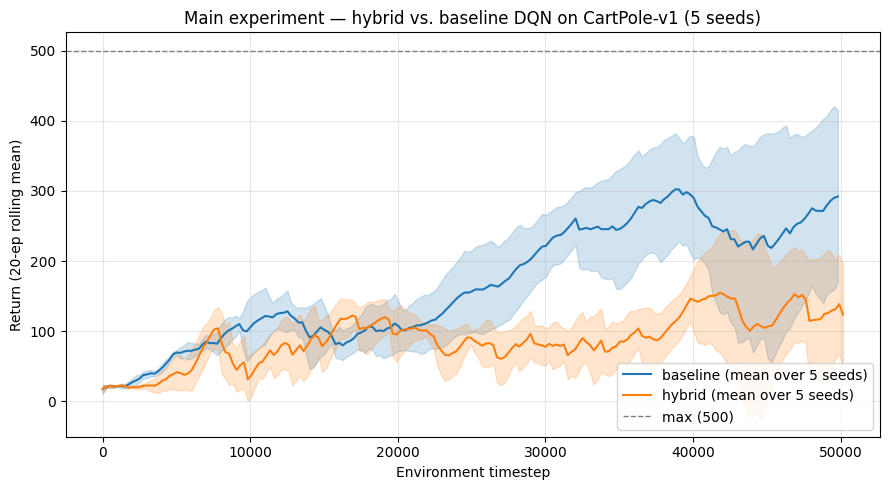

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
base_curves = load_curves('baseline_main', SEEDS)
hyb_curves  = load_curves('hybrid_main',  SEEDS)

g_b, m_b, s_b = stack_on_timestep_grid(base_curves)
g_h, m_h, s_h = stack_on_timestep_grid(hyb_curves)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(g_b, m_b, label='baseline (mean over 5 seeds)', color='tab:blue')
ax.fill_between(g_b, m_b - s_b, m_b + s_b, color='tab:blue', alpha=0.2)
ax.plot(g_h, m_h, label='hybrid (mean over 5 seeds)', color='tab:orange')
ax.fill_between(g_h, m_h - s_h, m_h + s_h, color='tab:orange', alpha=0.2)
ax.axhline(500, color='grey', linestyle='--', linewidth=1, label='max (500)')
ax.set_xlabel('Environment timestep')
ax.set_ylabel('Return (20-ep rolling mean)')
ax.set_title('Main experiment — hybrid vs. baseline DQN on CartPole-v1 (5 seeds)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'figures' / 'main_hybrid_vs_baseline.png', dpi=150)
plt.show()

In [12]:
# Per-seed summary table + significance test.
fr_b = final_returns(base_curves)
fr_h = final_returns(hyb_curves)

se_b = sample_efficiency(base_curves, target=400)
se_h = sample_efficiency(hyb_curves,  target=400)

t, p = stats.ttest_ind(fr_h, fr_b, equal_var=False)   # Welch t-test
rel = (np.mean(fr_h) - np.mean(fr_b)) / abs(np.mean(fr_b))

summary = pd.DataFrame([
    ['baseline', f'{np.mean(fr_b):.1f} ± {np.std(fr_b):.1f}',
                 f'{np.nanmean(se_b):.0f}' if not np.all(np.isnan(se_b)) else 'never'],
    ['hybrid  ', f'{np.mean(fr_h):.1f} ± {np.std(fr_h):.1f}',
                 f'{np.nanmean(se_h):.0f}' if not np.all(np.isnan(se_h)) else 'never'],
], columns=['mode', 'convergence score', 'steps to return=400'])

print(summary.to_string(index=False))
print()
print(f'relative improvement : {rel*100:+.1f}%')
print(f'Welch t-test         : t={t:.2f}, p={p:.3f}')

    mode convergence score steps to return=400
baseline      236.4 ± 98.6               41116
hybrid        102.8 ± 56.4               never

relative improvement : -56.5%
Welch t-test         : t=-2.35, p=0.054


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
import shutil

# Main experiment'taki default hybrid run'ları sweep klasörüne kopyala
# Böylece aynı deneyi iki kere yapmayız.
pairs = [
    # (sweep_filename, main_filename)
    ('beta5.0_seed{s}.csv', 'hybrid_main_seed{s}.csv'),
    ('cap100000_seed{s}.csv', 'hybrid_main_seed{s}.csv'),
    ('lr0.0023_seed{s}.csv', 'hybrid_main_seed{s}.csv'),
]

for s in [0, 1, 2]:
    for sweep_name, main_name in pairs:
        src = PROJECT_ROOT / 'logs' / main_name.format(s=s)
        dst = PROJECT_ROOT / 'logs' / 'sweeps' / sweep_name.format(s=s)
        if src.exists() and not dst.exists():
            shutil.copy(src, dst)
            print(f'copied {main_name.format(s=s)} -> sweeps/{sweep_name.format(s=s)}')
        elif dst.exists():
            print(f'already exists: sweeps/{sweep_name.format(s=s)}')

copied hybrid_main_seed0.csv -> sweeps/beta5.0_seed0.csv
copied hybrid_main_seed0.csv -> sweeps/cap100000_seed0.csv
copied hybrid_main_seed0.csv -> sweeps/lr0.0023_seed0.csv
copied hybrid_main_seed1.csv -> sweeps/beta5.0_seed1.csv
copied hybrid_main_seed1.csv -> sweeps/cap100000_seed1.csv
copied hybrid_main_seed1.csv -> sweeps/lr0.0023_seed1.csv
copied hybrid_main_seed2.csv -> sweeps/beta5.0_seed2.csv
copied hybrid_main_seed2.csv -> sweeps/cap100000_seed2.csv
copied hybrid_main_seed2.csv -> sweeps/lr0.0023_seed2.csv


## 7. Sweep 1 — Hopfield beta

Bio-inspired hyperparameter. 3 values × 3 seeds = 9 runs ~ 25 min.
(I use 3 seeds rather than 5 for the sweeps, which is standard practice;
the main experiment is the one that needs 5.)

In [15]:
BETA_VALUES = [1.0, 5.0, 10.0]
SWEEP_SEEDS = [0, 1, 2]

print('=== sweep 1 : Hopfield beta ===')
for beta in BETA_VALUES:
    for s in SWEEP_SEEDS:
        path = PROJECT_ROOT / 'logs' / 'sweeps' / f'beta{beta}_seed{s}.csv'
        _, elapsed, cached = run(path, seed=s, mode='hybrid', hopfield_beta=beta)
        tag = 'cached' if cached else f'{elapsed:.1f}s'
        print(f'  beta={beta:<4}  seed {s}  -> {tag}')

=== sweep 1 : Hopfield beta ===
  beta=1.0   seed 0  -> cached
  beta=1.0   seed 1  -> 181.5s
  beta=1.0   seed 2  -> 178.0s
  beta=5.0   seed 0  -> cached
  beta=5.0   seed 1  -> cached
  beta=5.0   seed 2  -> cached
  beta=10.0  seed 0  -> 180.9s
  beta=10.0  seed 1  -> 184.3s
  beta=10.0  seed 2  -> 188.5s


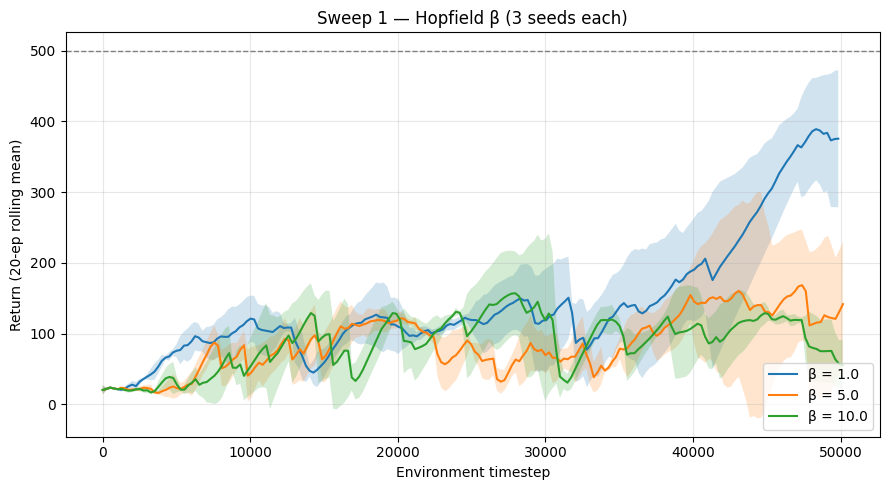

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
# Beta sweep plot: one curve per beta, mean across 3 seeds
fig, ax = plt.subplots(figsize=(9, 5))
for beta in BETA_VALUES:
    curves = {s: pd.read_csv(PROJECT_ROOT / 'logs' / 'sweeps' / f'beta{beta}_seed{s}.csv')
              for s in SWEEP_SEEDS}
    for df in curves.values():
        df['smooth'] = df['return'].rolling(20, min_periods=1).mean()
    g, m, sd = stack_on_timestep_grid(curves)
    ax.plot(g, m, label=f'β = {beta}')
    ax.fill_between(g, m - sd, m + sd, alpha=0.2)

ax.axhline(500, color='grey', linestyle='--', linewidth=1)
ax.set_xlabel('Environment timestep')
ax.set_ylabel('Return (20-ep rolling mean)')
ax.set_title('Sweep 1 — Hopfield β (3 seeds each)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'figures' / 'sweep_beta.png', dpi=150)
plt.show()

## 8. Sweep 2 — Hopfield capacity

Structural hyperparameter.

In [23]:
CAPACITIES = [1_000, 10_000, 100_000]

print('=== sweep 2 : Hopfield capacity ===')
for cap in CAPACITIES:
    for s in SWEEP_SEEDS:
        path = PROJECT_ROOT / 'logs' / 'sweeps' / f'cap{cap}_seed{s}.csv'
        _, elapsed, cached = run(path, seed=s, mode='hybrid', hopfield_capacity=cap)
        tag = 'cached' if cached else f'{elapsed:.1f}s'
        print(f'  cap={cap:<7}  seed {s}  -> {tag}')

=== sweep 2 : Hopfield capacity ===
  cap=1000     seed 0  -> 154.6s
  cap=1000     seed 1  -> 162.4s
  cap=1000     seed 2  -> 171.9s
  cap=10000    seed 0  -> 173.1s
  cap=10000    seed 1  -> 177.7s
  cap=10000    seed 2  -> 169.2s
  cap=100000   seed 0  -> cached
  cap=100000   seed 1  -> cached
  cap=100000   seed 2  -> cached


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


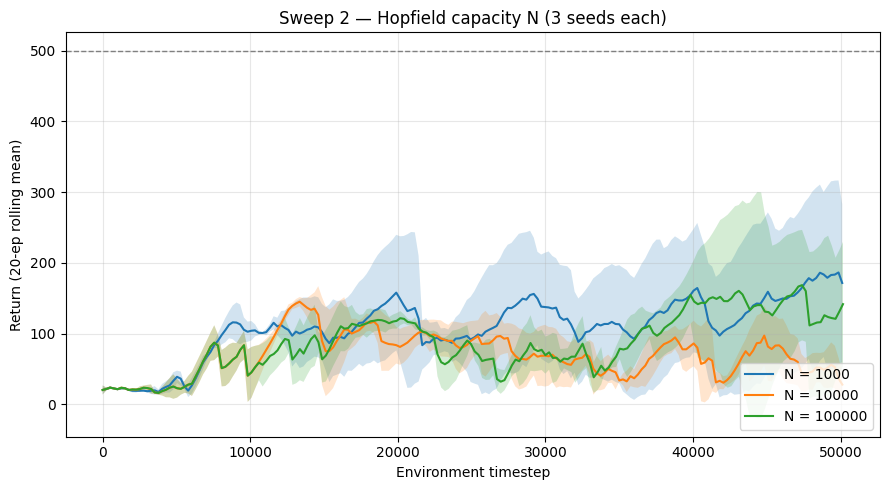

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
for cap in CAPACITIES:
    curves = {s: pd.read_csv(PROJECT_ROOT / 'logs' / 'sweeps' / f'cap{cap}_seed{s}.csv')
              for s in SWEEP_SEEDS}
    for df in curves.values():
        df['smooth'] = df['return'].rolling(20, min_periods=1).mean()
    g, m, sd = stack_on_timestep_grid(curves)
    ax.plot(g, m, label=f'N = {cap}')
    ax.fill_between(g, m - sd, m + sd, alpha=0.2)

ax.axhline(500, color='grey', linestyle='--', linewidth=1)
ax.set_xlabel('Environment timestep')
ax.set_ylabel('Return (20-ep rolling mean)')
ax.set_title('Sweep 2 — Hopfield capacity N (3 seeds each)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'figures' / 'sweep_capacity.png', dpi=150)
plt.show()

## 9. Sweep 3 — Learning rate (RL hyperparameter)

In [25]:
LEARNING_RATES = [5e-4, 2.3e-3, 5e-3]

print('=== sweep 3 : learning rate ===')
for lr in LEARNING_RATES:
    for s in SWEEP_SEEDS:
        path = PROJECT_ROOT / 'logs' / 'sweeps' / f'lr{lr}_seed{s}.csv'
        _, elapsed, cached = run(path, seed=s, mode='hybrid',
                                 overrides=dict(learning_rate=lr))
        tag = 'cached' if cached else f'{elapsed:.1f}s'
        print(f'  lr={lr:<8}  seed {s}  -> {tag}')

=== sweep 3 : learning rate ===
  lr=0.0005    seed 0  -> 169.5s
  lr=0.0005    seed 1  -> 163.4s
  lr=0.0005    seed 2  -> 167.4s
  lr=0.0023    seed 0  -> cached
  lr=0.0023    seed 1  -> cached
  lr=0.0023    seed 2  -> cached


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  lr=0.005     seed 0  -> 187.4s
  lr=0.005     seed 1  -> 188.4s
  lr=0.005     seed 2  -> 191.2s


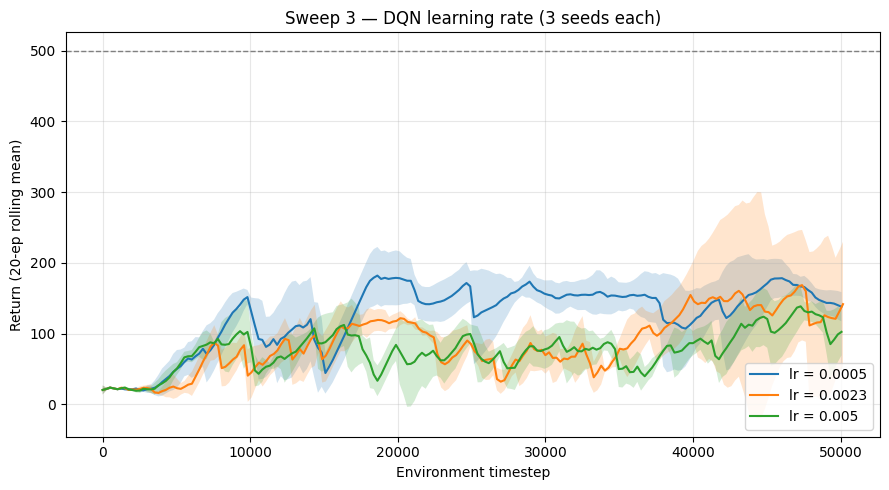

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
for lr in LEARNING_RATES:
    curves = {s: pd.read_csv(PROJECT_ROOT / 'logs' / 'sweeps' / f'lr{lr}_seed{s}.csv')
              for s in SWEEP_SEEDS}
    for df in curves.values():
        df['smooth'] = df['return'].rolling(20, min_periods=1).mean()
    g, m, sd = stack_on_timestep_grid(curves)
    ax.plot(g, m, label=f'lr = {lr}')
    ax.fill_between(g, m - sd, m + sd, alpha=0.2)

ax.axhline(500, color='grey', linestyle='--', linewidth=1)
ax.set_xlabel('Environment timestep')
ax.set_ylabel('Return (20-ep rolling mean)')
ax.set_title('Sweep 3 — DQN learning rate (3 seeds each)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'figures' / 'sweep_lr.png', dpi=150)
plt.show()

## 10. Sweep summary table

Final numbers (convergence score = mean return over last 10% of episodes)
for each sweep configuration.

In [27]:
def sweep_final(prefix, values, seeds):
    rows = []
    for v in values:
        finals = []
        for s in seeds:
            df = pd.read_csv(PROJECT_ROOT / 'logs' / 'sweeps' / f'{prefix}{v}_seed{s}.csv')
            finals.append(df['return'].tail(max(10, int(0.1 * len(df)))).mean())
        rows.append([v, np.mean(finals), np.std(finals)])
    return pd.DataFrame(rows, columns=['value', 'mean_final', 'std_final'])

print('--- sweep 1 : beta ---')
print(sweep_final('beta', BETA_VALUES, SWEEP_SEEDS).to_string(index=False))
print()
print('--- sweep 2 : capacity ---')
print(sweep_final('cap', CAPACITIES, SWEEP_SEEDS).to_string(index=False))
print()
print('--- sweep 3 : learning rate ---')
print(sweep_final('lr', LEARNING_RATES, SWEEP_SEEDS).to_string(index=False))

--- sweep 1 : beta ---
 value  mean_final  std_final
   1.0  256.847971  80.927010
   5.0  110.025235  71.352108
  10.0   66.126202  38.052580

--- sweep 2 : capacity ---
 value  mean_final  std_final
  1000  140.474581 103.450443
 10000   44.976106  23.610205
100000  110.025235  71.352108

--- sweep 3 : learning rate ---
 value  mean_final  std_final
0.0005  150.379583  24.307626
0.0023  110.025235  71.352108
0.0050  109.743213  20.869279


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [28]:
# ===== Best config (β=1.0) 5-seed validation =====
print('=== best config (β=1.0) — 5 seeds ===')
BEST_BETA = 1.0
ALL_SEEDS = [0, 1, 2, 3, 4]

for s in ALL_SEEDS:
    path = PROJECT_ROOT / 'logs' / f'best_seed{s}.csv'
    _, elapsed, cached = run(path, seed=s, mode='hybrid', hopfield_beta=BEST_BETA)
    tag = 'cached' if cached else f'{elapsed:.1f}s'
    print(f'  best (β={BEST_BETA}) seed {s}  -> {tag}')

print('best config experiment done.')

=== best config (β=1.0) — 5 seeds ===
  best (β=1.0) seed 0  -> 187.2s
  best (β=1.0) seed 1  -> 181.8s
  best (β=1.0) seed 2  -> 177.8s
  best (β=1.0) seed 3  -> 175.6s
  best (β=1.0) seed 4  -> 179.4s
best config experiment done.


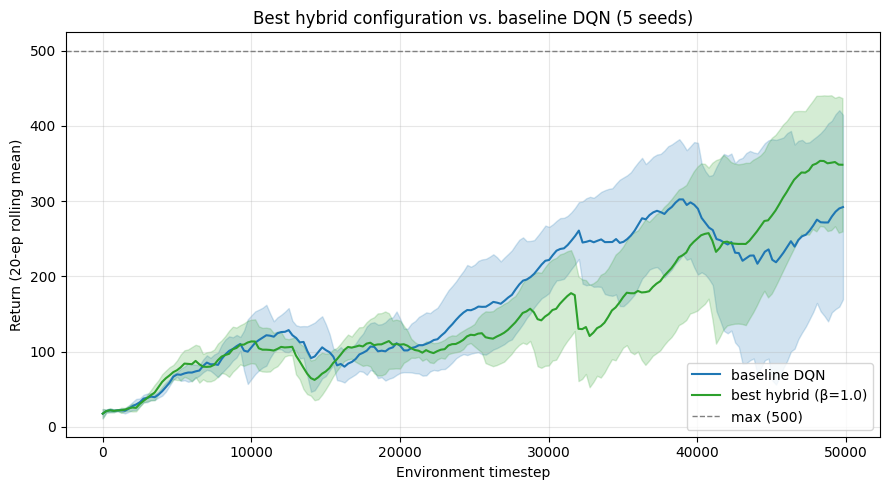

baseline final return  : 236.4 ± 98.6
best hybrid final return: 263.7 ± 82.0
relative improvement   : +11.5%
Welch t-test           : t=0.43, p=0.682


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:
# ===== Best hybrid vs baseline (5 seeds) =====
base_curves = load_curves('baseline_main', ALL_SEEDS)
best_curves = load_curves('best',          ALL_SEEDS)

g_b, m_b, s_b = stack_on_timestep_grid(base_curves)
g_h, m_h, s_h = stack_on_timestep_grid(best_curves)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(g_b, m_b, label='baseline DQN', color='tab:blue')
ax.fill_between(g_b, m_b - s_b, m_b + s_b, color='tab:blue', alpha=0.2)
ax.plot(g_h, m_h, label='best hybrid (β=1.0)', color='tab:green')
ax.fill_between(g_h, m_h - s_h, m_h + s_h, color='tab:green', alpha=0.2)
ax.axhline(500, color='grey', linestyle='--', linewidth=1, label='max (500)')
ax.set_xlabel('Environment timestep')
ax.set_ylabel('Return (20-ep rolling mean)')
ax.set_title('Best hybrid configuration vs. baseline DQN (5 seeds)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'figures' / 'best_vs_baseline.png', dpi=150)
plt.show()

# İstatistiksel karşılaştırma
fr_b = final_returns(base_curves)
fr_h = final_returns(best_curves)
t, p = stats.ttest_ind(fr_h, fr_b, equal_var=False)
rel = (np.mean(fr_h) - np.mean(fr_b)) / abs(np.mean(fr_b))

print(f'baseline final return  : {np.mean(fr_b):.1f} ± {np.std(fr_b):.1f}')
print(f'best hybrid final return: {np.mean(fr_h):.1f} ± {np.std(fr_h):.1f}')
print(f'relative improvement   : {rel*100:+.1f}%')
print(f'Welch t-test           : t={t:.2f}, p={p:.3f}')

## What I want from this notebook

- `figures/main_hybrid_vs_baseline.png` — headline figure for the report.
- A significance test (Welch t-test) between hybrid and baseline final
  returns.
- Three sweep plots + a table to answer the 'which bio-inspired parameter
  matters most?' evaluation question.
- All raw CSVs preserved in `logs/` for the `plot_results.py` script.